In [9]:
pip install wikipedia textstat ollama tqdm

Note: you may need to restart the kernel to use updated packages.


In [10]:
import wikipedia
import random
import json
import ollama
import textstat
from tqdm import tqdm

In [11]:
seed_topics = [
    "Physics", "Biology", "Mathematics",
    "History", "Technology", "Philosophy",
    "Chemistry", "Economics", "Geography",
    "Psychology", "Computer science",
    "Political science", "Astronomy",
    "Engineering", "Medicine"
]

concepts = []

for topic in seed_topics:
    try:
        results = wikipedia.search(topic, results=60)
        concepts.extend(results)
    except:
        continue

# Clean + deduplicate
concepts = list(set(concepts))

# Keep only clean titles (avoid weird formatting)
concepts = [c for c in concepts if len(c.split()) <= 5]

# Random sample 500
concepts = random.sample(concepts, min(500, len(concepts)))

print("Total concepts collected:", len(concepts))

Total concepts collected: 500


In [12]:
MODEL_NAME = "gemma2:2b" # change if needed

def generate(prompt):
    response = ollama.chat(
        model=MODEL_NAME,
        messages=[{"role": "user", "content": prompt}],
        options={
            "temperature": 0.8,
            "top_p": 0.9
        }
    )
    return response["message"]["content"].strip()

In [13]:
def elementary_prompt(concept):
    return f"""
Explain the concept of {concept} in a way that a 10-year-old can understand.
Use simple sentences.
Avoid technical terms.
Keep it clear and short.
"""

def intermediate_prompt(concept):
    return f"""
Explain the concept of {concept} at a high school level.
Use clear language and moderate detail.
You may introduce technical terms if needed.
"""

def advanced_prompt(concept):
    return f"""
Provide a detailed explanation of {concept} suitable for a university-level audience.
Use precise terminology and deeper conceptual discussion.
"""

In [14]:
!ollama list


NAME         ID              SIZE      MODIFIED     
gemma2:2b    8ccf136fdd52    1.6 GB    3 months ago    


In [17]:
dataset = []

for idx, concept in enumerate(tqdm(concepts), 1):

    try:
        print(f"\n--- [{idx}/{len(concepts)}] Processing: {concept} ---")

        elem = generate(elementary_prompt(concept))
        print("  ✓ Elementary generated")

        inter = generate(intermediate_prompt(concept))
        print("  ✓ Intermediate generated")

        adv = generate(advanced_prompt(concept))
        print("  ✓ Advanced generated")

        dataset.append({
            "concept": concept,
            "elementary": elem,
            "intermediate": inter,
            "advanced": adv
        })

        print("  ✔ Saved to dataset")

    except Exception as e:
        print(f"Skipping {concept} due to error:", e)
        continue

print("\nGenerated entries:", len(dataset))

  0%|          | 0/500 [00:00<?, ?it/s]


--- [1/500] Processing: Moral geography ---
  ✓ Elementary generated
  ✓ Intermediate generated


  0%|          | 1/500 [00:26<3:41:12, 26.60s/it]

  ✓ Advanced generated
  ✔ Saved to dataset

--- [2/500] Processing: World history (disambiguation) ---
  ✓ Elementary generated
  ✓ Intermediate generated


  0%|          | 2/500 [00:58<4:08:36, 29.95s/it]

...

  ✓ Advanced generated
  ✔ Saved to dataset

--- [499/500] Processing: Engineering & Technology ---
  ✓ Elementary generated
  ✓ Intermediate generated


100%|█████████▉| 499/500 [8:13:32<00:37, 37.03s/it]

  ✓ Advanced generated
  ✔ Saved to dataset

--- [500/500] Processing: Goods ---
  ✓ Elementary generated
  ✓ Intermediate generated


100%|██████████| 500/500 [8:14:08<00:00, 59.30s/it]

  ✓ Advanced generated
  ✔ Saved to dataset

Generated entries: 500


In [18]:
import textstat

def compute_scores(text):
    return {
        "fre": textstat.flesch_reading_ease(text),
        "fkgl": textstat.flesch_kincaid_grade(text)
    }

for item in dataset:
    item["scores"] = {
        "elementary": compute_scores(item["elementary"]),
        "intermediate": compute_scores(item["intermediate"]),
        "advanced": compute_scores(item["advanced"])
    }

print("Scores computed.")

Scores computed.


In [19]:
clean_dataset = []

for item in dataset:
    fre_e = item["scores"]["elementary"]["fre"]
    fre_i = item["scores"]["intermediate"]["fre"]
    fre_a = item["scores"]["advanced"]["fre"]

    fk_e = item["scores"]["elementary"]["fkgl"]
    fk_i = item["scores"]["intermediate"]["fkgl"]
    fk_a = item["scores"]["advanced"]["fkgl"]

    if (fre_e > fre_i > fre_a) and (fk_e < fk_i < fk_a):
        clean_dataset.append(item)

print("Original size:", len(dataset))
print("After filtering:", len(clean_dataset))

Original size: 500
After filtering: 491


In [21]:
!pip install matplotlib

  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.1 MB 3.7 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.1 MB 4.6 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.1 MB 4.6 MB/s eta 0:00:02
   --------------------- ------------------ 4.5/8.1 MB 4.8 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.1 MB 5.0 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.1 MB 4.9 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.1 MB 5.1 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 5.0 MB/s  0:00:01
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   --------------------------------- ------ 1.3/1.6 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------

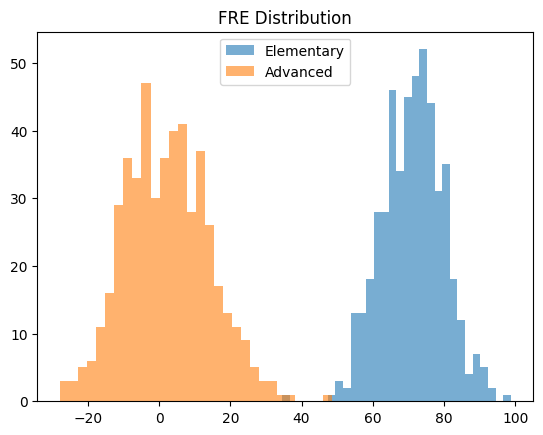

In [22]:
import matplotlib.pyplot as plt

fre_elem = [x["scores"]["elementary"]["fre"] for x in clean_dataset]
fre_adv = [x["scores"]["advanced"]["fre"] for x in clean_dataset]

plt.hist(fre_elem, bins=30, alpha=0.6, label="Elementary")
plt.hist(fre_adv, bins=30, alpha=0.6, label="Advanced")
plt.legend()
plt.title("FRE Distribution")
plt.show()

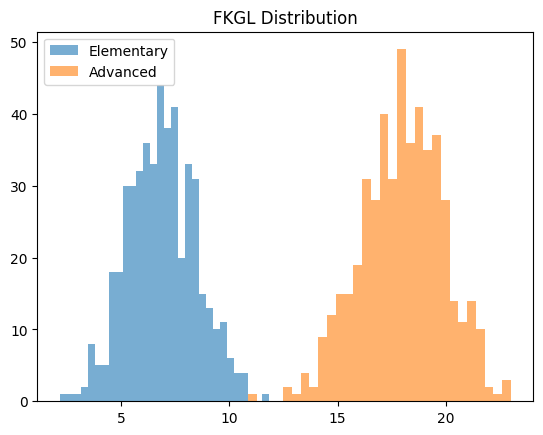

In [23]:
fk_elem = [x["scores"]["elementary"]["fkgl"] for x in clean_dataset]
fk_adv = [x["scores"]["advanced"]["fkgl"] for x in clean_dataset]

plt.hist(fk_elem, bins=30, alpha=0.6, label="Elementary")
plt.hist(fk_adv, bins=30, alpha=0.6, label="Advanced")
plt.legend()
plt.title("FKGL Distribution")
plt.show()

In [24]:
import json

with open("explanation_dataset_clean.json", "w") as f:
    json.dump(clean_dataset, f, indent=2)

print("Saved clean dataset:", len(clean_dataset))

Saved clean dataset: 491


In [25]:
import numpy as np

def cohens_d(a, b):
    return (np.mean(a) - np.mean(b)) / np.sqrt(
        (np.var(a) + np.var(b)) / 2
    )

d_fre = cohens_d(fre_elem, fre_adv)
d_fk = cohens_d(fk_elem, fk_adv)

print("Cohen's d (FRE):", d_fre)
print("Cohen's d (FKGL):", d_fk)

Cohen's d (FRE): 6.637153920195672
Cohen's d (FKGL): -6.33890604624903
